# Cleaned Dataset Statistics
Analysis of `cleaned_cs2_games_pregame.csv` to understand data distributions and win patterns.

In [1]:
# AI used for formatting of the notebook (the markdown sections)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("../../data/cleaned_cs2_games_pregame.csv")
print(f"Dataset loaded. Shape: {df.shape}")

Dataset loaded. Shape: (5569, 22)


## 1. Overview and Data Quality
Checking for missing values, unique counts, and basic structure.

In [3]:
# info and missing values
print("Missing values per column:")
print(df.isnull().sum())

# unique counts
unique_counts = {
    'Tournaments': df['tournament'].nunique(),
    'Teams': len(pd.unique(df[['team1', 'team2']].values.ravel())),
    'Players': len(pd.unique(df[['team1_player1_id', 'team1_player2_id', 'team1_player3_id', 'team1_player4_id', 'team1_player5_id', 'team2_player1_id', 'team2_player2_id', 'team2_player3_id', 'team2_player4_id', 'team2_player5_id']].values.ravel())),
    'Maps': df['map_name'].nunique()
}
print("\nUnique counts:")
for k, v in unique_counts.items():
    print(f"{k}: {v}")

Missing values per column:
tournament          0
team1_id            0
team1               0
team2_id            0
team2               0
bestOf              0
map_name            0
team1_win           0
team1_player1_id    0
team1_player2_id    0
team1_player3_id    0
team1_player4_id    0
team1_player5_id    0
team2_player1_id    0
team2_player2_id    0
team2_player3_id    0
team2_player4_id    0
team2_player5_id    0
year                0
month               0
day_of_week         0
hour                0
dtype: int64

Unique counts:
Tournaments: 116
Teams: 193
Players: 770
Maps: 10


## 2. Target Variable Analysis
Analyzing `team1_win` distribution.

Win Rate Distribution (0 = Team 2 Win, 1 = Team 1 Win):
team1_win
1    0.546956
0    0.453044
Name: proportion, dtype: float64


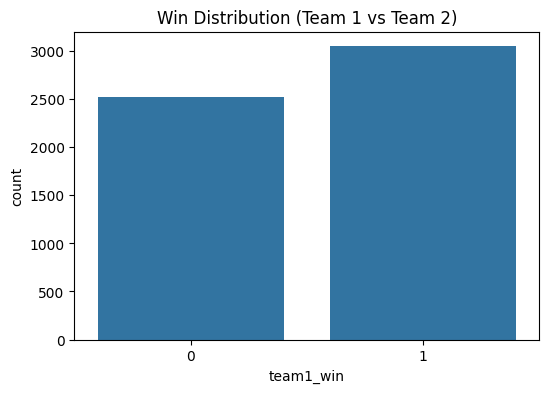

In [4]:
# win rate distribution
win_rate = df['team1_win'].value_counts(normalize=True)
print("Win Rate Distribution (0 = Team 2 Win, 1 = Team 1 Win):")
print(win_rate)

# plot win rate
plt.figure(figsize=(6, 4))
sns.countplot(x='team1_win', data=df)
plt.title('Win Distribution (Team 1 vs Team 2)')
plt.show()

## 3. Categorical Distributions
Maps and Tournaments frequency.

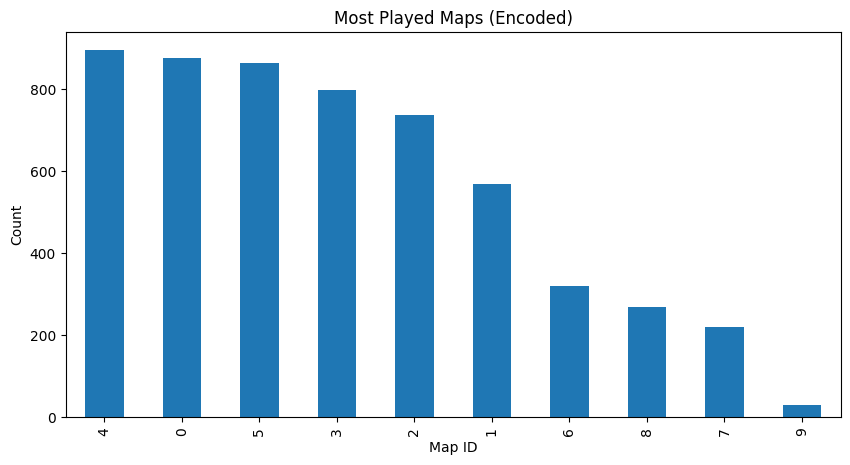

Match Format (Best Of) Distribution:
bestOf
3.0    4969
1.0     437
5.0     163
Name: count, dtype: int64


In [5]:
# map popularity
plt.figure(figsize=(10, 5))
df['map_name'].value_counts().plot(kind='bar')
plt.title('Most Played Maps (Encoded)')
plt.xlabel('Map ID')
plt.ylabel('Count')
plt.show()

# bestof distribution
print("Match Format (Best Of) Distribution:")
print(df['bestOf'].value_counts())

## 4. Temporal Analysis
Matches by year, month, and hour.

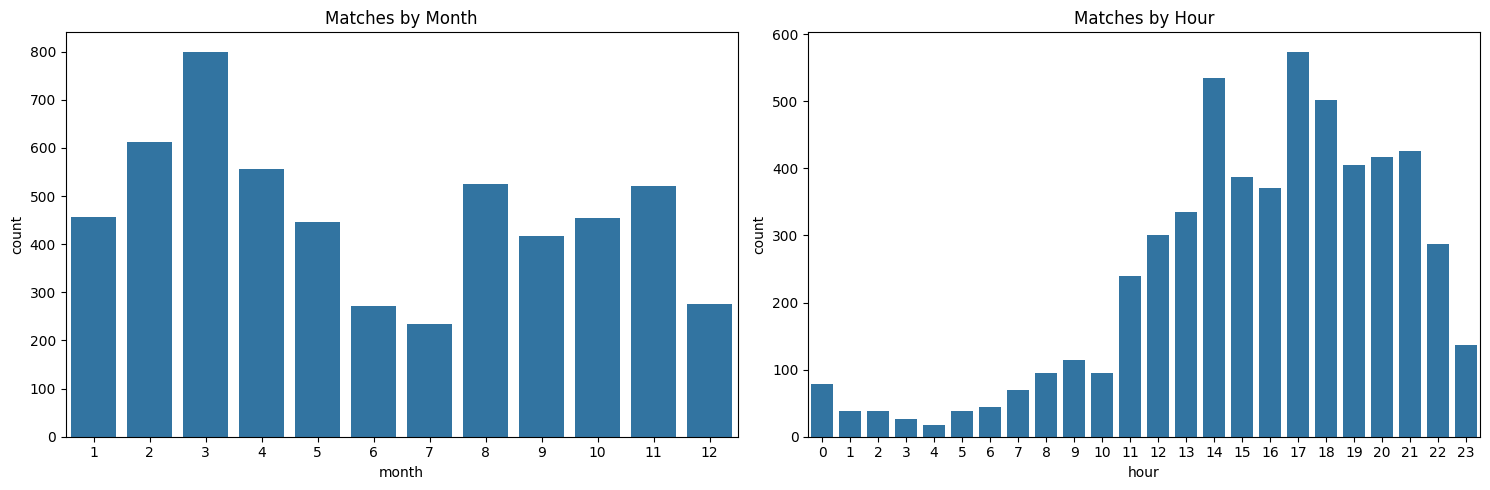

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# matches by month
sns.countplot(x='month', data=df, ax=axes[0])
axes[0].set_title('Matches by Month')

# matches by hour
sns.countplot(x='hour', data=df, ax=axes[1])
axes[1].set_title('Matches by Hour')

plt.tight_layout()
plt.show()

## 5. Team and Player Wins
Identifying most successful teams and players.

In [7]:
# calculate team wins
team1_wins = df[df['team1_win'] == 1]['team1'].value_counts()
team2_wins = df[df['team1_win'] == 0]['team2'].value_counts()
total_team_wins = team1_wins.add(team2_wins, fill_value=0).sort_values(ascending=False)

print("Top 10 Teams by Wins (Encoded ID):")
print(total_team_wins.head(10))

# calculate player wins
# each match has 5 players on each team. 
p_cols_t1 = [f'team1_player{i}_id' for i in range(1, 6)]
p_cols_t2 = [f'team2_player{i}_id' for i in range(1, 6)]

t1_win_players = df[df['team1_win'] == 1][p_cols_t1].values.flatten()
t2_win_players = df[df['team1_win'] == 0][p_cols_t2].values.flatten()

winning_players = pd.Series([*t1_win_players, *t2_win_players])
winning_players = winning_players[winning_players != -1] # remove placeholder
player_win_counts = winning_players.value_counts().sort_values(ascending=False)

print("\nTop 10 Players by Wins (ID):")
print(player_win_counts.head(10))

Top 10 Teams by Wins (Encoded ID):
63     242.0
61     231.0
112    215.0
177    199.0
122    154.0
175    153.0
71     143.0
188    124.0
181    117.0
57     110.0
Name: count, dtype: float64

Top 10 Players by Wins (ID):
146.0     313
19.0      283
550.0     283
1549.0    283
1443.0    280
26.0      254
2611.0    245
2041.0    245
4710.0    245
28.0      242
Name: count, dtype: int64
